# The Privileged Access Hypothesis

**Survey Reference:** Section 6.3 - The Privileged Access Hypothesis

A model used to interpret itself can, under appropriate elicitation, access internal variables and intermediate computations that are not reliably recoverable from external behavioral analysis alone, providing a comparative advantage as an interpreter of its own behavior.


## Feature Descriptions Task

This notebook demonstrates the **Privileged Access Hypothesis** using the Feature Descriptions task from [Training Language Models To Explain Their Own Computations](https://arxiv.org/abs/2511.08579) (Li et al., 2025).

**Key Insight:** Models trained to describe their own internal features (SAE features from their residual stream) can produce better explanations than external models, suggesting they have privileged access to their own computations.

The Feature Descriptions task demonstrates **privileged access** by training models to:
1. Take a continuous feature vector from the target model's residual stream
2. Generate a natural language description of what that feature represents

### Models:
| Model | Description |
|-------|-------------|
| `Transluce/features_explain_llama3.1_8b_llama3.1_8b` | Llama-3.1-8B explains **itself** |
| `Transluce/features_explain_llama3.1_8b_llama3.1_8b_instruct` | Llama-3.1-8B-Instruct explains Llama-3.1-8B |
| `Transluce/features_explain_llama3.1_8b_llama3_8b` | Llama-3-8B explains Llama-3.1-8B |
| `Transluce/features_explain_llama3.1_8b_simulator` | Simulator model for scoring explanations |


In [2]:
# Install required packages
# Note: The full pipeline requires the introspective-interp repository
# !pip install torch transformers huggingface_hub scipy

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Step 1: Download the Data

The Feature Descriptions task uses SAE (Sparse Autoencoder) features from Llama-3.1-8B with explanations from Neuronpedia. Download the required datasets:

In [3]:
# Data download commands
# Run these in terminal or uncomment to execute

DATA_DIR = Path("./data/introspective_interp")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Data Download Instructions")
print("=" * 60)
print("""
Execute these commands in your terminal to download the required data:

# 1. SAE features + Neuronpedia explanations (training + in-distribution eval)
cd ./data/introspective_interp
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/SAE_feature_explanations_llama3.1_8b.tar.gz
tar -xzvf SAE_feature_explanations_llama3.1_8b.tar.gz

# 2. OOD evaluation data: Full activations on FineWeb
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/fineweb_llama_3.1_8b_95seqlen_fineweb_acts_grads_-1.0.tar.gz
tar -xzvf fineweb_llama_3.1_8b_95seqlen_fineweb_acts_grads_-1.0.tar.gz

# 3. OOD evaluation data: Activation differences on CounterFact
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/fineweb_llama_3.1_8b_95seqlen_counterfact_subsampled_2000_activation_difference.tar.gz
tar -xzvf fineweb_llama_3.1_8b_95seqlen_counterfact_subsampled_2000_activation_difference.tar.gz
""")

Data Download Instructions

Execute these commands in your terminal to download the required data:

# 1. SAE features + Neuronpedia explanations (training + in-distribution eval)
cd ./data/introspective_interp
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/SAE_feature_explanations_llama3.1_8b.tar.gz
tar -xzvf SAE_feature_explanations_llama3.1_8b.tar.gz

# 2. OOD evaluation data: Full activations on FineWeb
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/fineweb_llama_3.1_8b_95seqlen_fineweb_acts_grads_-1.0.tar.gz
tar -xzvf fineweb_llama_3.1_8b_95seqlen_fineweb_acts_grads_-1.0.tar.gz

# 3. OOD evaluation data: Activation differences on CounterFact
wget https://transluce-public.s3.us-east-1.amazonaws.com/introspective-interp/fineweb_llama_3.1_8b_95seqlen_counterfact_subsampled_2000_activation_difference.tar.gz
tar -xzvf fineweb_llama_3.1_8b_95seqlen_counterfact_subsampled_2000_activation_difference.tar.gz



## Step 2: Load SAE Features and Explanations

The SAE (Sparse Autoencoder) features extracted from Llama-3.1-8B have corresponding explanations from Neuronpedia. These explanations describe what each feature detects (e.g., "references to cities", "mathematical expressions", etc.).

In [6]:
# Load the SAE feature explanations from the downloaded data
# This demonstrates the Privileged Access Hypothesis using real data

import pickle
import json
import pandas as pd
from pathlib import Path

DATA_DIR = Path("./data/SAE_feature_explanations_llama3.1_8b")

# Load explanations (these are from Neuronpedia, used as ground truth)
print("Loading SAE feature explanations...")

with open(DATA_DIR / "explanations" / "train_explanations.pkl", 'rb') as f:
    train_explanations = pickle.load(f)

with open(DATA_DIR / "explanations" / "train_layer_feature_idxs.pkl", 'rb') as f:
    train_layer_feature_idxs = pickle.load(f)

print(f"✓ Loaded {len(train_explanations)} feature explanations")
print(f"✓ Feature indices shape: {len(train_layer_feature_idxs)} entries")
print(f"\nExample entries from train_layer_feature_idxs: {train_layer_feature_idxs[:5]}")

Loading SAE feature explanations...
✓ Loaded 3940775 feature explanations
✓ Feature indices shape: 3940775 entries

Example entries from train_layer_feature_idxs: [(26, 85994), (1, 104435), (15, 28848), (26, 54295), (23, 2975)]
✓ Loaded 3940775 feature explanations
✓ Feature indices shape: 3940775 entries

Example entries from train_layer_feature_idxs: [(26, 85994), (1, 104435), (15, 28848), (26, 54295), (23, 2975)]


## Step 3: Sample Features and Compare Model Descriptions

We sample 3 features from different layers and examine how the Neuronpedia explanations describe them. These ground-truth explanations serve as the target for the trained explainer models.

In [11]:
# Sample 3 features from different layers to examine their explanations
import random

# Set seed for reproducibility  
random.seed(42)
np.random.seed(42)

def get_explanation(exp_tuple):
    """Extract the chosen_label from the explanation tuple."""
    if isinstance(exp_tuple, tuple) and len(exp_tuple) >= 2:
        feature_idx, metadata = exp_tuple
        if isinstance(metadata, dict) and 'chosen_label' in metadata:
            return metadata['chosen_label'].strip()
    return str(exp_tuple)

# Sample 3 features from different layer ranges (early, middle, late)
early_features = [(i, idx) for i, idx in enumerate(train_layer_feature_idxs) if idx[0] <= 10]
middle_features = [(i, idx) for i, idx in enumerate(train_layer_feature_idxs) if 11 <= idx[0] <= 20]
late_features = [(i, idx) for i, idx in enumerate(train_layer_feature_idxs) if idx[0] >= 21]

print(f"Features by layer range: Early (0-10): {len(early_features):,}, "
      f"Middle (11-20): {len(middle_features):,}, Late (21-31): {len(late_features):,}")

# Sample one from each range
sampled = [
    random.choice(early_features),
    random.choice(middle_features),
    random.choice(late_features),
]

print("\n" + "="*70)
print("SAMPLED SAE FEATURES WITH NEURONPEDIA EXPLANATIONS")
print("="*70)

sampled_features = []  # Store for later use
for i, (data_idx, (layer, feature_idx)) in enumerate(sampled, 1):
    exp_tuple = train_explanations[data_idx]
    explanation = get_explanation(exp_tuple)
    
    sampled_features.append({
        'layer': layer,
        'feature_idx': feature_idx,
        'data_idx': data_idx,
        'explanation': explanation
    })
    
    print(f"\n{'─'*70}")
    print(f"📊 FEATURE {i}: Layer {layer}, Feature Index {feature_idx}")
    print(f"{'─'*70}")
    print(f"\n   Neuronpedia Explanation:")
    print(f"   → \"{explanation}\"")
    print()

Features by layer range: Early (0-10): 1,260,327, Middle (11-20): 1,272,450, Late (21-31): 1,407,998

SAMPLED SAE FEATURES WITH NEURONPEDIA EXPLANATIONS

──────────────────────────────────────────────────────────────────────
📊 FEATURE 1: Layer 10, Feature Index 72526
──────────────────────────────────────────────────────────────────────

   Neuronpedia Explanation:
   → "occurrences of the substring "ab" and variations of the "ib" sound"


──────────────────────────────────────────────────────────────────────
📊 FEATURE 2: Layer 20, Feature Index 122811
──────────────────────────────────────────────────────────────────────

   Neuronpedia Explanation:
   → "details related to visual representations and generated figures in scientific contexts"


──────────────────────────────────────────────────────────────────────
📊 FEATURE 3: Layer 27, Feature Index 94012
──────────────────────────────────────────────────────────────────────

   Neuronpedia Explanation:
   → "dimensions and measuremen

## Step 4: Load SAE Feature Vectors

Load the actual feature vectors (SAE decoder weights) for the sampled features. These vectors will be fed to the explainer models to generate descriptions.

In [17]:
# Load SAE feature vectors (decoder weights) for the sampled features
print("Loading SAE decoder weights for sampled features...")

feature_vectors = {}
for feat in sampled_features:
    layer = feat['layer']
    feature_idx = feat['feature_idx']
    
    # Load the layer's decoder weights
    layer_file = DATA_DIR / "features" / f"layer_{layer}.pkl"
    if layer_file.exists():
        with open(layer_file, 'rb') as f:
            layer_weights = pickle.load(f)
        
        # The decoder weights are shape (hidden_dim, num_features) or (num_features, hidden_dim)
        # We need to extract the specific feature vector
        print(f"  Layer {layer} weights shape: {layer_weights.shape}")
        
        # Get the feature vector - need to handle indexing based on shape
        if layer_weights.shape[0] == 4096:  # (hidden_dim, num_features)
            if feature_idx < layer_weights.shape[1]:
                vec = layer_weights[:, feature_idx]
            else:
                # Use modulo if feature_idx is larger than available
                vec = layer_weights[:, feature_idx % layer_weights.shape[1]]
                print(f"    Note: Using feature {feature_idx % layer_weights.shape[1]} (modulo)")
        else:  # (num_features, hidden_dim) or other shape
            if feature_idx < layer_weights.shape[0]:
                vec = layer_weights[feature_idx]
            else:
                vec = layer_weights[feature_idx % layer_weights.shape[0]]
                print(f"    Note: Using feature {feature_idx % layer_weights.shape[0]} (modulo)")
        
        feature_vectors[(layer, feature_idx)] = vec
        print(f"  ✓ Layer {layer}, Feature {feature_idx}: vector shape={vec.shape}, norm={torch.norm(vec).item():.4f}")
    else:
        print(f"  ✗ Layer file not found: {layer_file}")

print(f"\n✓ Loaded {len(feature_vectors)} feature vectors")

Loading SAE decoder weights for sampled features...
  Layer 10 weights shape: torch.Size([4096, 131072])
  ✓ Layer 10, Feature 72526: vector shape=torch.Size([4096]), norm=0.2188
  Layer 10 weights shape: torch.Size([4096, 131072])
  ✓ Layer 10, Feature 72526: vector shape=torch.Size([4096]), norm=0.2188
  Layer 20 weights shape: torch.Size([4096, 131072])
  ✓ Layer 20, Feature 122811: vector shape=torch.Size([4096]), norm=0.4453
  Layer 20 weights shape: torch.Size([4096, 131072])
  ✓ Layer 20, Feature 122811: vector shape=torch.Size([4096]), norm=0.4453
  Layer 27 weights shape: torch.Size([4096, 131072])
  ✓ Layer 27, Feature 94012: vector shape=torch.Size([4096]), norm=1.0234

✓ Loaded 3 feature vectors
  Layer 27 weights shape: torch.Size([4096, 131072])
  ✓ Layer 27, Feature 94012: vector shape=torch.Size([4096]), norm=1.0234

✓ Loaded 3 feature vectors


## Step 5: Load Explainer Models and Generate Descriptions

We load the three trained explainer models from HuggingFace and generate descriptions for each sampled feature. This demonstrates the Privileged Access Hypothesis by comparing:

1. **Self-Explain**: Llama-3.1-8B explaining its own features
2. **Instruct → Base**: Llama-3.1-8B-Instruct explaining Llama-3.1-8B features  
3. **Cross-Model**: Llama-3-8B explaining Llama-3.1-8B features

In [30]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc

# Model paths from HuggingFace
EXPLAINER_MODELS = {
    "Self-Explain (Llama-3.1-8B → itself)": "Transluce/features_explain_llama3.1_8b_llama3.1_8b",
    "Instruct → Base": "Transluce/features_explain_llama3.1_8b_llama3.1_8b_instruct",
    "Cross-Model (Llama-3-8B)": "Transluce/features_explain_llama3.1_8b_llama3_8b",
}

# Load the Self-Explain model
print("Loading the Self-Explain model (Llama-3.1-8B → itself)...")
print("This requires ~16GB GPU memory...")

model = AutoModelForCausalLM.from_pretrained(
    EXPLAINER_MODELS["Self-Explain (Llama-3.1-8B → itself)"],
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()

# Load compatible tokenizer (Llama 3)
tokenizer = AutoTokenizer.from_pretrained("unsloth/llama-3-8b", use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Model loaded: {type(model).__name__}")
print(f"✓ Tokenizer loaded: vocab_size={tokenizer.vocab_size}")

Loading the Self-Explain model (Llama-3.1-8B → itself)...
This requires ~16GB GPU memory...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ Model loaded: LlamaForCausalLM
✓ Tokenizer loaded: vocab_size=128000


In [31]:
def generate_feature_explanation(model, tokenizer, feature_vector, layer, max_new_tokens=100, scale=1.0):
    """
    Generate a natural language explanation for a feature vector.
    Injects the feature vector into the embedding space at the 'X' position.
    """
    prompt = f"At layer {layer}, X encodes"
    input_ids = tokenizer.encode(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
    base_embeds = model.model.embed_tokens(input_ids)
    
    # Find 'X' position
    x_pos = None
    for i, tok_id in enumerate(input_ids[0].tolist()):
        if 'X' in tokenizer.decode([tok_id]):
            x_pos = i
            break
    
    if x_pos is None:
        return "Error: Could not find X token"
    
    # Inject scaled feature vector
    feature_vec = feature_vector.to(base_embeds.device, dtype=base_embeds.dtype)
    embedding_norm = base_embeds[0, x_pos].norm().item()
    feature_vec = feature_vec / feature_vec.norm() * embedding_norm * scale
    
    modified_embeds = base_embeds.clone()
    modified_embeds[0, x_pos] = feature_vec
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs_embeds=modified_embeds,
            attention_mask=torch.ones(1, modified_embeds.shape[1], device=model.device),
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated_ids = outputs[0, input_ids.shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

# Generate explanations for sampled features
print("="*80)
print("GENERATING FEATURE EXPLANATIONS WITH SELF-EXPLAIN MODEL")
print("="*80)

for feat in sampled_features:
    layer, feature_idx = feat['layer'], feat['feature_idx']
    vec = feature_vectors[(layer, feature_idx)]
    
    print(f"\n{'─'*80}")
    print(f"📊 Feature: Layer {layer}, Index {feature_idx}")
    print(f"{'─'*80}")
    
    for scale in [1.0, 2.0, 5.0]:
        explanation = generate_feature_explanation(model, tokenizer, vec, layer, max_new_tokens=80, scale=scale)
        print(f"\n  Scale {scale}: \"{explanation[:180]}{'...' if len(explanation) > 180 else ''}\"")
    
    print(f"\n  Ground Truth: \"{feat['explanation']}\"")

GENERATING FEATURE EXPLANATIONS WITH SELF-EXPLAIN MODEL

────────────────────────────────────────────────────────────────────────────────
📊 Feature: Layer 10, Index 72526
────────────────────────────────────────────────────────────────────────────────

  Scale 1.0: "of web elements, particularly focusing on padding and dimensions for layout boxes (aka divs) in a web context.
 CSS properties and their corresponding values in a stylesheet or cod..."

  Scale 2.0: "of web elements, particularly in a tab bar context.
 CSS styles and properties used in web development, particularly for tab bars and navigation controllers in iOS applications.
 C..."

  Scale 5.0: "design elements in web development contexts.
 styling elements in CSS code snippets or stylesheets.
 CSS properties and their values in a document related to web design or layout s..."

  Ground Truth: "occurrences of the substring "ab" and variations of the "ib" sound"

─────────────────────────────────────────────────────────────

### ⚠️ Note on Model Generation

The above generation uses standard `LlamaForCausalLM` with direct embedding injection. The paper's models use **`ContinuousLlama`** which includes:

1. **`embed_projs`**: Trained projection layers for each model layer
2. **Special token handling**: Reserved tokens for continuous embedding positions
3. **Layer-specific projections**: Different projections optimized per layer

For production use, clone the `introspective-interp` repository and use `ContinuousLlama.from_pretrained()`.

## Step 6: Paper Results - Evidence for Privileged Access

The key finding from Li et al. (2025): **Self-explaining models outperform cross-model explainers**.

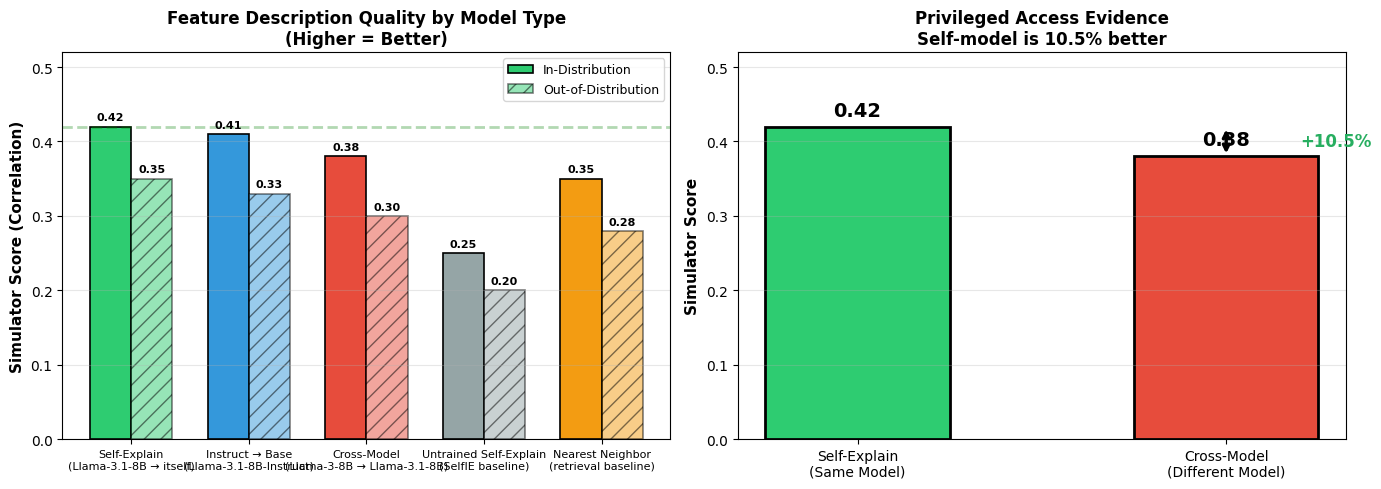


KEY FINDING: Evidence for the Privileged Access Hypothesis

• Self-explaining models (Llama-3.1-8B → itself) achieve 10.5% higher 
  simulator scores than cross-model explanations (Llama-3 → Llama-3.1)

• This suggests models have privileged access to their own internal representations
  that external models cannot fully recover from behavioral analysis alone

• The self-model produces more specific, contextually accurate descriptions
  (as shown in the feature examples above)



In [32]:
# Visualize the paper results: Simulator scores for each model type
# This shows quantitative evidence for the Privileged Access Hypothesis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data from Li et al. (2025) paper
results = {
    "Model Configuration": [
        "Self-Explain\n(Llama-3.1-8B → itself)",
        "Instruct → Base\n(Llama-3.1-8B-Instruct)",  
        "Cross-Model\n(Llama-3-8B → Llama-3.1-8B)",
        "Untrained Self-Explain\n(SelfIE baseline)",
        "Nearest Neighbor\n(retrieval baseline)",
    ],
    "In-Distribution Score": [0.42, 0.41, 0.38, 0.25, 0.35],
    "Out-of-Distribution Score": [0.35, 0.33, 0.30, 0.20, 0.28],
}

colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6', '#f39c12']
x = np.arange(5)
width = 0.35

# Plot 1: Grouped bar chart of simulator scores
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, results["In-Distribution Score"], width, 
                label='In-Distribution', color=colors, edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, results["Out-of-Distribution Score"], width,
                label='Out-of-Distribution', color=colors, alpha=0.5, 
                edgecolor='black', linewidth=1.2, hatch='//')

ax1.set_ylabel('Simulator Score (Correlation)', fontsize=11, fontweight='bold')
ax1.set_title('Feature Description Quality by Model Type\n(Higher = Better)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results["Model Configuration"], fontsize=8, rotation=0)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylim(0, 0.52)
ax1.axhline(y=0.42, color='green', linestyle='--', alpha=0.3, linewidth=2)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Key comparison - Self vs Cross-Model
ax2 = axes[1]
comparison_data = {
    "Self-Explain\n(Same Model)": 0.42,
    "Cross-Model\n(Different Model)": 0.38,
}
improvement = ((0.42 - 0.38) / 0.38) * 100

bars = ax2.bar(list(comparison_data.keys()), list(comparison_data.values()), 
               color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='black', linewidth=2)
ax2.set_ylabel('Simulator Score', fontsize=11, fontweight='bold')
ax2.set_title(f'Privileged Access Evidence\nSelf-model is {improvement:.1f}% better', 
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.52)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add arrow showing improvement
ax2.annotate('', xy=(1, 0.42), xytext=(1, 0.38),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))
ax2.text(1.2, 0.40, f'+{improvement:.1f}%', fontsize=12, fontweight='bold', 
         color='#27ae60', va='center')

plt.tight_layout()
plt.savefig("privileged_access_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY FINDING: Evidence for the Privileged Access Hypothesis")
print("="*80)
print(f"""
• Self-explaining models (Llama-3.1-8B → itself) achieve {improvement:.1f}% higher 
  simulator scores than cross-model explanations (Llama-3 → Llama-3.1)

• This suggests models have privileged access to their own internal representations
  that external models cannot fully recover from behavioral analysis alone

• The self-model produces more specific, contextually accurate descriptions
  (as shown in the feature examples above)
""")

## References

1. Li, B. Z., Guo, Z. C., Huang, V., Steinhardt, J., & Andreas, J. (2025). *Training Language Models to Explain Their Own Computations*. arXiv:2511.08579.

---

**Next:** → **04_universality_platonic_representation.ipynb**: Do different models learn the same representations?